In [1]:
# import libraries

import pandas as pd
import numpy as np

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

In [5]:
# load data

df = pd.read_csv('../Data_Processing/preprocessed_data.csv')
df["datetime_utc12"] = pd.to_datetime(df["datetime_utc12"])

df = df.sort_values("datetime_utc12").reset_index(drop=True)

target_col = "el_price_dol_MWh_OTA2201"

In [6]:
# Remove all other electricity price columns
# Keep only the target price column

price_cols_to_drop = [
    c for c in df.columns
    if "el_price" in c and c != target_col
]

print("Price columns to drop:")
print(price_cols_to_drop)

df = df.drop(columns=price_cols_to_drop)

print("Remaining dataframe shape:", df.shape)

Price columns to drop:
['el_price_dol_MWh_BEN2201', 'el_price_dol_MWh_HAY2201', 'el_price_dol_MWh_INV2201', 'el_price_dol_MWh_ISL2201', 'el_price_dol_MWh_KIK2201', 'el_price_dol_MWh_RDF2201', 'el_price_dol_MWh_SFD2201', 'el_price_dol_MWh_WKM2201']
Remaining dataframe shape: (52585, 73)


In [7]:
# # Remove only rows created by shifting
# df = df.dropna(subset=price_cols).reset_index(drop=True)

In [8]:
# print("XGBoost dataframe shape:", df.shape)
# print("Shifted price columns:", len(price_cols))

In [9]:
# print("Rows before:", len(df))

# df = df.dropna(subset=price_cols)

# print("Rows after:", len(df))
# print("Rows removed:", len_before - len(df))

In [10]:
print("Remaining dataframe shape:", df.shape)

price_cols_check = [
    c for c in df.columns
    if "el_price" in c and c != target_col
]

print("Remaining other price columns:", price_cols_check)

Remaining dataframe shape: (52585, 73)
Remaining other price columns: []


In [11]:
df = df.ffill()

In [12]:
# Create cyclical time features

import numpy as np

# Basic time components
df["hour"] = df["datetime_utc12"].dt.hour
df["dayofweek"] = df["datetime_utc12"].dt.dayofweek
df["month"] = df["datetime_utc12"].dt.month
df["dayofyear"] = df["datetime_utc12"].dt.dayofyear

# Weekend indicator
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

# -----------------------------
# Cyclical encoding
# -----------------------------

# Hour
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# Day of week
df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

# Month
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

print("Time features created successfully.")

Time features created successfully.


In [13]:
# Create target lag features: daily, weekly, yearly

# Daily lag: same hour yesterday
df["target_lag_24h"] = df[target_col].shift(24)

# Weekly lag: same hour last week
df["target_lag_168h"] = df[target_col].shift(168)

# Yearly lag: same hour last year
df["target_lag_8760h"] = df[target_col].shift(8760)

print("Target lag features created.")
print(df[["target_lag_24h", "target_lag_168h", "target_lag_8760h"]].isna().sum())

Target lag features created.
target_lag_24h        24
target_lag_168h      168
target_lag_8760h    8760
dtype: int64


In [14]:
# Leakage-safe rolling window features

# -----------------------------------
# Daily rolling features (24h)
# -----------------------------------

df["rolling_mean_24h"] = (
    df[target_col]
    .shift(1)
    .rolling(window=24)
    .mean()
)

df["rolling_std_24h"] = (
    df[target_col]
    .shift(1)
    .rolling(window=24)
    .std()
)

# -----------------------------------
# Weekly rolling features (168h)
# -----------------------------------

df["rolling_mean_168h"] = (
    df[target_col]
    .shift(1)
    .rolling(window=168)
    .mean()
)

df["rolling_std_168h"] = (
    df[target_col]
    .shift(1)
    .rolling(window=168)
    .std()
)

# -----------------------------------
# Yearly rolling features (8760h)
# -----------------------------------

df["rolling_mean_8760h"] = (
    df[target_col]
    .shift(1)
    .rolling(window=8760)
    .mean()
)

df["rolling_std_8760h"] = (
    df[target_col]
    .shift(1)
    .rolling(window=8760)
    .std()
)

print("Rolling window features created successfully.")

print(df[[
    "rolling_mean_24h",
    "rolling_mean_168h",
    "rolling_mean_8760h"
]].isna().sum())

Rolling window features created successfully.
rolling_mean_24h        24
rolling_mean_168h      168
rolling_mean_8760h    8760
dtype: int64


In [15]:
# Check missing values before final cleanup

missing_summary = df.isna().sum()

missing_summary = missing_summary[missing_summary > 0]

print(missing_summary.sort_values(ascending=False).head(20))

target_lag_8760h      8760
rolling_mean_8760h    8760
rolling_std_8760h     8760
target_lag_168h        168
rolling_mean_168h      168
rolling_std_168h       168
target_lag_24h          24
rolling_mean_24h        24
rolling_std_24h         24
dtype: int64


In [16]:
# Final cleanup after all feature engineering

rows_before = len(df)

df = df.dropna().reset_index(drop=True)

rows_after = len(df)

print(f"Rows before cleanup: {rows_before}")
print(f"Rows after cleanup: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")

Rows before cleanup: 52585
Rows after cleanup: 43825
Rows removed: 8760


In [17]:
# Define target

target_col = "el_price_dol_MWh_OTA2201"

# Exclude non-feature columns

exclude_cols = [
    "datetime_utc12",
    target_col
]

# Create feature list

feature_cols = [
    c for c in df.columns
    if c not in exclude_cols
]

# Define X and y

X = df[feature_cols]
y = df[target_col]

# Check shapes

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Number of features:", len(feature_cols))

# Confirm other electricity price columns were removed

remaining_price_cols = [
    c for c in X.columns
    if "el_price" in c
]

print("Remaining price columns in X:")
print(remaining_price_cols)

Feature matrix shape: (43825, 91)
Target shape: (43825,)
Number of features: 91
Remaining price columns in X:
[]


In [18]:
# Check missing values before final cleanup

missing_summary = df.isna().sum()
missing_summary = missing_summary[missing_summary > 0]

print(missing_summary.sort_values(ascending=False).head(30))

Series([], dtype: int64)


In [19]:
# Final cleanup after all feature engineering

rows_before = len(df)

df = df.dropna().reset_index(drop=True)

rows_after = len(df)

print(f"Rows before cleanup: {rows_before}")
print(f"Rows after cleanup: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")

Rows before cleanup: 43825
Rows after cleanup: 43825
Rows removed: 0


In [20]:
# Define target and features

target_col = "el_price_dol_MWh_OTA2201"

# Exclude non-feature columns

exclude_cols = [
    "datetime_utc12",
    target_col
]

# Create feature list

feature_cols = [
    c for c in df.columns
    if c not in exclude_cols
]

# Define X and y

X = df[feature_cols]
y = df[target_col]

# Check shapes

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Number of features:", len(feature_cols))

# Confirm no electricity price columns remain

remaining_price_cols = [
    c for c in X.columns
    if "el_price" in c
]

print("\nRemaining electricity price columns:")
print(remaining_price_cols)

Feature matrix shape: (43825, 91)
Target shape: (43825,)
Number of features: 91

Remaining electricity price columns:
[]


In [21]:
# -----------------------------------
# Time-based Train/Test Split
# -----------------------------------

split_ratio = 0.8

split_index = int(len(df) * split_ratio)

# Training data
X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

# Testing data
X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain period:")
print(df["datetime_utc12"].iloc[0], "to",
      df["datetime_utc12"].iloc[split_index - 1])

print("\nTest period:")
print(df["datetime_utc12"].iloc[split_index], "to",
      df["datetime_utc12"].iloc[-1])

Train shape: (35060, 91)
Test shape: (8765, 91)

Train period:
2020-01-01 00:00:00 to 2023-12-31 19:00:00

Test period:
2023-12-31 20:00:00 to 2024-12-31 00:00:00


In [22]:
# Train XGBoost model

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [23]:
# Make predictions

y_pred = xgb_model.predict(X_test)

print("Predictions completed.")
print(y_pred[:10])

Predictions completed.
[78.72837   62.08611   45.897533  37.295     32.230923  34.03179
 31.957415  25.897425   4.5420713 14.176793 ]


In [24]:
# Evaluate model performance

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 52.2829
RMSE : 117.3609
R²   : 0.6121


In [25]:
# Time-series cross validation

tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []
r2_scores = []

fold = 1

for train_index, test_index in tscv.split(X):

    # Split data
    X_train_cv = X.iloc[train_index]
    X_test_cv = X.iloc[test_index]

    y_train_cv = y.iloc[train_index]
    y_test_cv = y.iloc[test_index]

    # Train model
    model_cv = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model_cv.fit(X_train_cv, y_train_cv)

    # Predict
    y_pred_cv = model_cv.predict(X_test_cv)

    # Metrics
    mae = mean_absolute_error(y_test_cv, y_pred_cv)

    rmse = np.sqrt(
        mean_squared_error(y_test_cv, y_pred_cv)
    )

    r2 = r2_score(y_test_cv, y_pred_cv)

    # Store results
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

    print(f"\nFold {fold}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    fold += 1


Fold 1
MAE  : 55.1599
RMSE : 83.7432
R²   : 0.4634

Fold 2
MAE  : 35.1329
RMSE : 53.1110
R²   : 0.6503

Fold 3
MAE  : 41.1803
RMSE : 66.6020
R²   : 0.5022

Fold 4
MAE  : 41.9402
RMSE : 80.9279
R²   : 0.4884

Fold 5
MAE  : 52.7149
RMSE : 122.2062
R²   : 0.6298


In [26]:
print("\nAverage Cross-Validation Results")

print(f"Average MAE  : {np.mean(mae_scores):.4f}")
print(f"Average RMSE : {np.mean(rmse_scores):.4f}")
print(f"Average R²   : {np.mean(r2_scores):.4f}")


Average Cross-Validation Results
Average MAE  : 45.2256
Average RMSE : 81.3181
Average R²   : 0.5468


In [27]:
# Feature importance

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print(importance_df.head(20))

                       feature  importance
85            rolling_mean_24h    0.199669
82              target_lag_24h    0.118135
1                       Diesel    0.075402
37        SI_TKA__lake_level_m    0.029794
62              demand_GWh_USI    0.021698
89          rolling_mean_8760h    0.019629
61              demand_GWh_UNI    0.019099
35             tauranga_temp_c    0.017826
5                        Hydro    0.016369
31             auckland_temp_c    0.015370
3                          Gas    0.015160
38  SI_TKA__active_storage_mm³    0.014992
60              demand_GWh_LSI    0.013921
0                         Coal    0.013796
48  SI_HWE__active_storage_mm³    0.013604
43        NI_WKA__lake_level_m    0.013356
87           rolling_mean_168h    0.013092
19      auckland_shortwave_wm2    0.012733
33           wellington_temp_c    0.011650
70              outage_UNKN_MW    0.011515


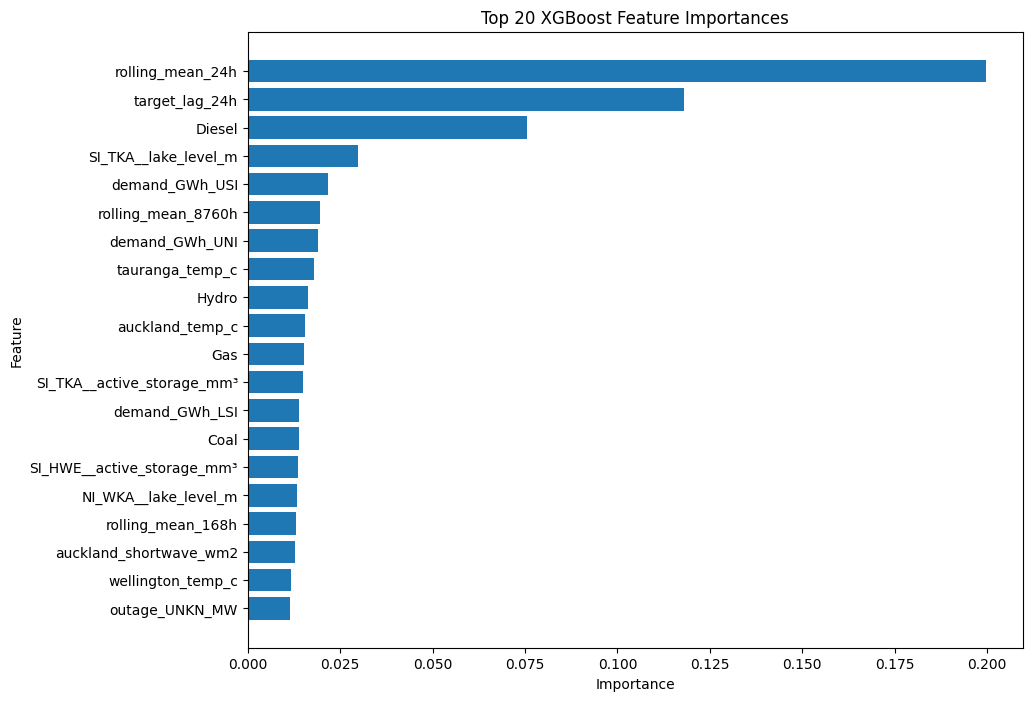

In [28]:
import matplotlib.pyplot as plt

# Top 20 feature importance

top_features = importance_df.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Top 20 XGBoost Feature Importances")

plt.show()

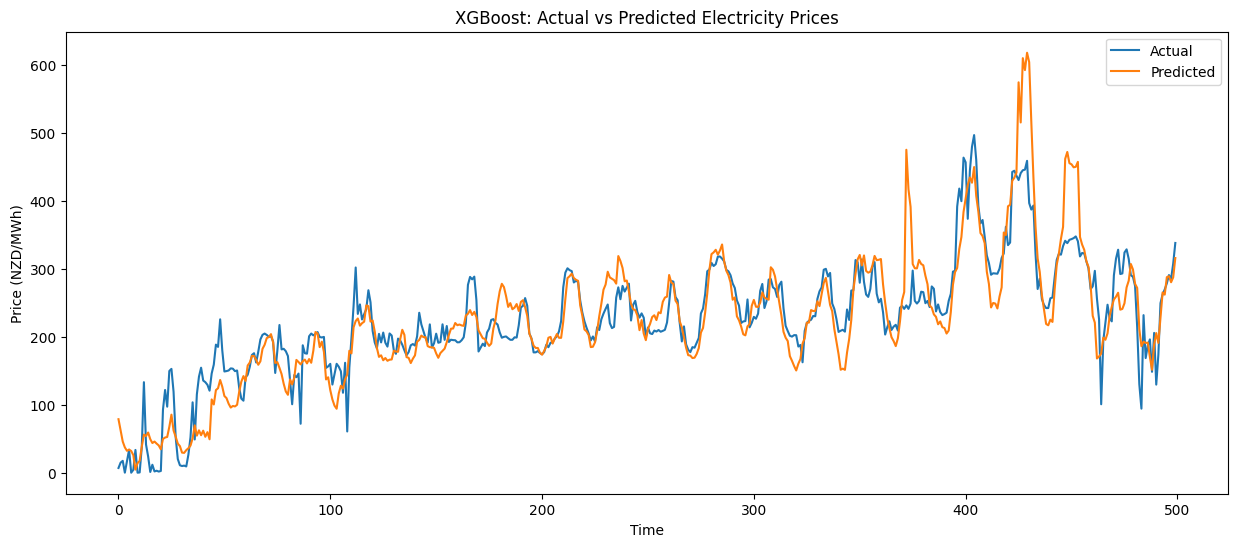

In [31]:
import matplotlib.pyplot as plt

# Plot actual vs predicted

plt.figure(figsize=(15,6))

plt.plot(
    y_test.values[:500],
    label="Actual"
)

plt.plot(
    y_pred[:500],
    label="Predicted"
)

plt.title("XGBoost: Actual vs Predicted Electricity Prices")
plt.xlabel("Time")
plt.ylabel("Price (NZD/MWh)")

plt.legend()

plt.show()